In [1]:
import datetime
import json
import os

from typing import TypedDict, Annotated, List, Union
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", temperature=0.2)

In [3]:
class BookingState(TypedDict):
    user_msg: str           # The raw input from the client
    client_name: str        # Extracted name
    client_email: str       # Extracted email
    appointment_time: str   # ISO format for Calendar
    calendar_link: str      # Link to the calendar event (added in Node 2)
    duration: str           # e.g., "30m"
    meeting_link: str       # Generated by Google Calendar
    owner_email: str        # (the business owner)
    status: str             # "pending", "scheduled", "failed"
    final_response: str         # The message to send back to the client

In [4]:
CURRENT_SCOPES = ['https://www.googleapis.com/auth/calendar', 'https://www.googleapis.com/auth/gmail.send']
token_path = os.path.join("..", "token.json")
creds = Credentials.from_authorized_user_file(token_path, CURRENT_SCOPES)

In [5]:
def parse_request(state: BookingState) -> BookingState:
    today = datetime.datetime.now().strftime("%A, %B %d, %Y")
    
    # SYSTEM PROMPT style instruction
    instruction = f"""
    You are a data extraction sub-routine. 
    Today is {today}.
    USER MESSAGE: "{state['user_msg']}"

    TASK: Extract meeting details.
    
    STRICT RULES:
    1. Return ONLY a raw JSON object. 
    2. Do NOT include any conversational text, greetings, or explanations.
    3. If a name is missing, use "Valued Client".
    4. Format the time as YYYY-MM-DD HH:MM.

    JSON STRUCTURE:
    {{
      "name": "...",
      "email": "...",
      "time": "...",
      "reason": "..."
    }}
    """
    
    response = model.invoke(instruction)
    
    # DEBUG: See exactly what's coming in
    print(f"DEBUG: Model returned type {type(response.content)}")
    
    # Logic to handle that 'List' format you just saw
    raw_text = ""
    if isinstance(response.content, list):
        # Look for the 'text' key in the list items
        for item in response.content:
            if isinstance(item, dict) and 'text' in item:
                raw_text += item['text']
    else:
        raw_text = str(response.content)

    try:
        # Final clean and load
        clean_json = raw_text.replace("```json", "").replace("```", "").strip()
        data = json.loads(clean_json)
        
        state['client_name'] = data.get("name", "Valued Client")
        state['client_email'] = data.get("email")
        state['appointment_time'] = data.get("time")
        state['status'] = "parsed"
        print(f"✅ Successfully Parsed: {state['client_name']}")
    except Exception as e:
        print(f"❌ Parser failed to find JSON. Model said: {raw_text[:100]}...")
        state['status'] = "error"
        
    return state

In [6]:
def check_conflicts(state: BookingState) -> BookingState:
    # If the parser failed, don't even try to talk to Google
    if state.get('status') == "error" or not state.get('appointment_time'):
        print("🛑 Skipping Conflict Check: Parser failed to find a time.")
        return state
    creds = Credentials.from_authorized_user_file(token_path, CURRENT_SCOPES)
    service = build('calendar', 'v3', credentials=creds)
    
    start_dt = datetime.datetime.fromisoformat(state['appointment_time'].replace(" ", "T"))
    end_dt = start_dt + datetime.timedelta(minutes=30)
    
    body = {
        "timeMin": start_dt.isoformat() + "Z",
        "timeMax": end_dt.isoformat() + "Z",
        "items": [{"id": "primary"}]
    }
    
    query = service.freebusy().query(body=body).execute()
    busy_slots = query['calendars']['primary']['busy']
    
    if busy_slots:
        print("⚠️ CONFLICT DETECTED: You are busy at this time!")
        state['status'] = "conflict"
    else:
        print("✅ Slot is free. Proceeding to approval.")
        state['status'] = "ready_for_approval"
    return state

In [7]:
def human_approval(state: BookingState) -> BookingState:
    if state['status'] != "ready_for_approval": return state
    
    print(f"\n--- PENDING APPROVAL ---")
    print(f"Client: {state['client_email']}")
    print(f"Time: {state['appointment_time']}")
    
    decision = input("Confirm booking? (yes/no): ").lower()
    
    if decision == 'yes':
        state['approver_decision'] = "approved"
        state['status'] = "approved"
    else:
        state['approver_decision'] = "rejected"
        state['status'] = "aborted"
    return state

In [8]:
def schedule_meeting(state: BookingState) -> BookingState:
    if state['status'] != "approved": return state # Change: Only run if approved!
    
    try:
        creds = Credentials.from_authorized_user_file(token_path, CURRENT_SCOPES)
        service = build('calendar', 'v3', credentials=creds)
        
        start_dt = datetime.datetime.fromisoformat(state['appointment_time'].replace(" ", "T"))
        end_dt = start_dt + datetime.timedelta(minutes=30)

        event = {
            'summary': 'AI Consultation - Quantum Solutions PK',
            'description': f"Client: {state['client_email']}\nMessage: {state['user_msg']}",
            'start': {'dateTime': start_dt.isoformat(), 'timeZone': 'Asia/Karachi'},
            'end': {'dateTime': end_dt.isoformat(), 'timeZone': 'Asia/Karachi'},
            'attendees': [{'email': state['client_email']}],
            'conferenceData': {'createRequest': {'requestId': "sample123", 'conferenceSolutionKey': {'type': 'hangoutsMeet'}}}
        }

        created_event = service.events().insert(
            calendarId='primary', 
            body=event, 
            conferenceDataVersion=1
        ).execute()

        state['meeting_link'] = created_event.get('hangoutLink')
        state['calendar_link'] = created_event.get('htmlLink') # IMPORTANT: Add this!
        state['status'] = "scheduled"
    except Exception as e:
        print(f"Calendar Error: {e}")
        state['status'] = "error"
    return state

In [9]:
def draft_notification(state: BookingState) -> BookingState:
    if state.get('status') != "scheduled": return state
    
    # Use real variables from state
    name = state.get('client_name', 'Client')
    m_link = state.get('meeting_link', '')
    c_link = state.get('calendar_link', '')

    prompt = f"""
    Write a professional, warm meeting confirmation email.
    Sender: Soomro, Lead AI Engineer at Quantum Solutions PK.
    Recipient: {name}
    Time: {state['appointment_time']} (PKT)
    
    STRICT RULES:
    1. Start with "Hi {name},"
    2. Provide the Google Meet link plainly: {m_link}
    3. Provide the Calendar Invite link plainly: {c_link}
    4. Do NOT use markdown brackets [](). 
    5. Mention: "Please use the Calendar Link to RSVP so I know you're coming!"
    6. End with "Genuine Regards," and your professional signature.
    """
    
    state['final_response'] = model.invoke(prompt).content
    return state

In [10]:
import base64
from email.message import EmailMessage

def send_gmail(state: BookingState) -> BookingState:
    if state.get('status') != "scheduled": 
        return state
    
    try:
        creds = Credentials.from_authorized_user_file(token_path, CURRENT_SCOPES)
        service = build('gmail', 'v1', credentials=creds)
        
        # --- FIX: Handle the 'list' return type ---
        email_content = state.get('final_response', "")
        
        # If Gemini returned a list of dictionaries, extract the text
        if isinstance(email_content, list):
            actual_text = ""
            for part in email_content:
                if isinstance(part, dict) and 'text' in part:
                    actual_text += part['text']
            email_content = actual_text

        msg = EmailMessage()
        msg.set_content(email_content) # Use the cleaned text
        msg['Subject'] = "Meeting Confirmed - Quantum Solutions PK"
        msg['From'] = "naveedsoomro585@gmail.com" # Your authenticated email
        msg['To'] = state.get('client_email')
        
        encoded_message = base64.urlsafe_b64encode(msg.as_bytes()).decode()
        create_message = {'raw': encoded_message}
        
        service.users().messages().send(userId="me", body=create_message).execute()
        print(f"📧 SUCCESS: Email sent to {state['client_email']}!")
        state['status'] = "completed"
        
    except Exception as e:
        print(f"❌ Gmail Error: {e}")
        state['status'] = "error"
        
    return state

In [11]:
builder = StateGraph(BookingState)

builder.add_node("parse", parse_request)
builder.add_node("check", check_conflicts)
builder.add_node("approve", human_approval)
builder.add_node("book", schedule_meeting) # Uses your previous calendar code
builder.add_node("notify", draft_notification)
builder.add_node("send", send_gmail)

builder.add_edge(START, "parse")
builder.add_edge("parse", "check")
builder.add_edge("check", "approve")
builder.add_edge("approve", "book")
builder.add_edge("book", "notify")
builder.add_edge("notify", "send")
builder.add_edge("send", END)

# Compile the agent
agent = builder.compile()

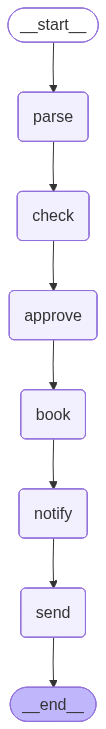

In [12]:
agent

In [14]:
# 1. Define the input (The human's message)
initial_state = {"user_msg": "Hi, I am Nehan. Can we meet tomorrow at 2am? My email is soomronaveed185@gmail.com"}

# 2. RUN THE AGENT (This is what creates the 'result' box)
result = agent.invoke(initial_state)

# 3. Now your print statements will work!
print("\n--- ✅ SUCCESS! ---")
print(f"Meeting Link: {result.get('meeting_link')}")

DEBUG: Model returned type <class 'list'>
✅ Successfully Parsed: Nehan
✅ Slot is free. Proceeding to approval.

--- PENDING APPROVAL ---
Client: soomronaveed185@gmail.com
Time: 2026-04-08 02:00
📧 SUCCESS: Email sent to soomronaveed185@gmail.com!

--- ✅ SUCCESS! ---
Meeting Link: https://meet.google.com/rtv-snvo-ije
